In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

features_df = pd.read_csv('data/features_df_v1.csv')
mX = features_df.loc[:, "f1_mass_PC1":].astype(float).values
data_df = pd.read_csv('data/waka_dragon_merged.csv')
vY = data_df['Imax'].astype(float).values

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import RANSACRegressor

In [4]:
vC = [0.01, 0.1, 1, 10, 100, 1000]
vEpsilon = [0.01, 0.05, 0.1, 0.5, 1.0]
vGamma = ['scale', 'auto', 0.001, 0.01, 0.1, 1]

lParamGrid = [
    {'kernel': ['linear'], 'C': vC, 'epsilon': vEpsilon},
    {'kernel': ['rbf'], 'C': vC, 'epsilon': vEpsilon, 'gamma': vGamma},
    {
        'kernel': ['poly'], 'C': vC, 'epsilon': vEpsilon,
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        'degree': [2, 3, 4], 'coef0': [0.0, 0.1, 1.0],
    },
    {
        'kernel': ['sigmoid'], 'C': vC, 'epsilon': vEpsilon,
        'gamma': ['scale', 'auto', 0.01, 0.1, 1], 'coef0': [0.0, 0.1, 1.0],
    },
]

In [5]:
kf = KFold(n_splits=len(vY), shuffle=True, random_state=42)

oGsSvr = GridSearchCV(
    estimator=SVR(max_iter=50_000),
    param_grid=lParamGrid,
    scoring='neg_mean_absolute_error',
    cv=kf,
    n_jobs=-1,
    verbose=2,
)
oGsSvr.fit(mX, vY)

print(f'Best LOOCV MAE: {-oGsSvr.best_score_:.2f}')
print('Best parameters:', oGsSvr.best_params_)

Fitting 312 folds for each of 2010 candidates, totalling 627120 fits
Best LOOCV MAE: 8.65
Best parameters: {'C': 10, 'coef0': 1.0, 'degree': 2, 'epsilon': 1.0, 'gamma': 0.001, 'kernel': 'poly'}


In [6]:
#Now let's train the best model on whole dataset
oSvr_best = SVR(**oGsSvr.best_params_).fit(mX, vY)

vY_pred = oSvr_best.predict(mX)

mae = mean_absolute_error(vY, vY_pred)
print(f'MAE: {mae:.2f}')

r2 = r2_score(vY, vY_pred)
print(f'R2: {r2:.2f}')

MAE: 7.11
R2: 0.61


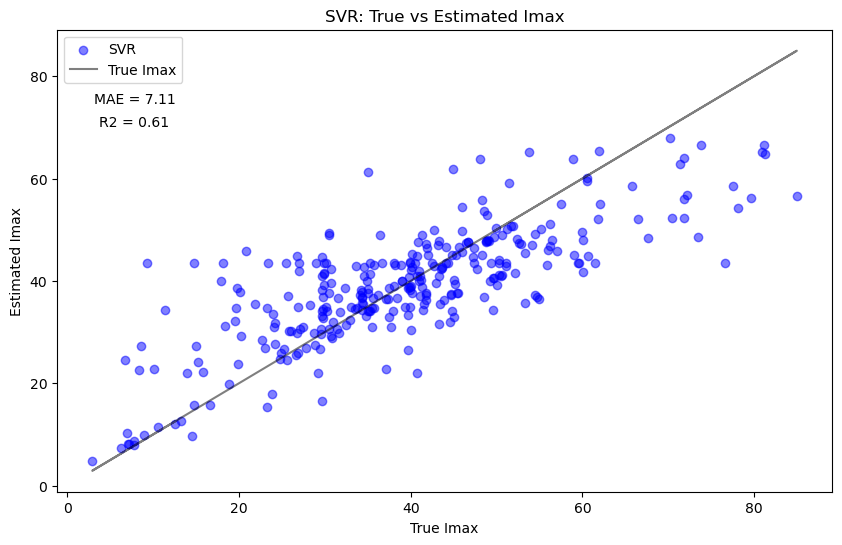

In [7]:
# now let's plot the results
plt.figure(figsize=(10, 6))
plt.scatter(vY, vY_pred, label='SVR', color='blue', alpha=0.5)
plt.plot(vY, vY, label='True Imax', color='black', alpha=0.5)
plt.xlabel('True Imax')
plt.ylabel('Estimated Imax')
plt.title('SVR: True vs Estimated Imax')
plt.text(0.1, 0.85, f'MAE = {mae:.2f}', transform=plt.gca().transAxes, ha='center', va='center')
plt.text(0.1, 0.8, f'R2 = {r2:.2f}', transform=plt.gca().transAxes, ha='center', va='center')
plt.legend()
plt.show()

In [11]:
minNumSamples = np.linspace(0.4, 0.98, 50)  # narrower than Ridge; SVR needs enough points
ransac_results_df = pd.DataFrame({
    'min_samples': minNumSamples,
    'R2': 0.0, 'MAE': 0.0, 'RMSE': 0.0, 'MSE': 0.0,
})

oSvrBase = SVR(**oGsSvr.best_params_, max_iter=50_000)

for i, min_samples in enumerate(minNumSamples):
    oRansac = RANSACRegressor(
        estimator=oSvrBase,
        min_samples=min_samples,
        max_trials=10000,          # 10_000 like Ridge is very slow with SVR
        random_state=42,
    )
    oRansac.fit(mX, vY)
    vY_pred_ransac = oRansac.predict(mX)
    ransac_results_df.loc[i, 'R2'] = r2_score(vY, vY_pred_ransac)
    ransac_results_df.loc[i, 'MAE'] = mean_absolute_error(vY, vY_pred_ransac)
    ransac_results_df.loc[i, 'RMSE'] = np.sqrt(mean_squared_error(vY, vY_pred_ransac))
    ransac_results_df.loc[i, 'MSE'] = mean_squared_error(vY, vY_pred_ransac)

optimal_min_samples = ransac_results_df.loc[ransac_results_df['MAE'].idxmin(), 'min_samples']
ransac_results_df.sort_values('MAE').head()

,min_samples,R2,MAE,RMSE,MSE
49,0.980000,0.569602,7.354628,10.239694,104.851330
40,0.873469,0.569858,7.360005,10.236643,104.788858
48,0.968163,0.566911,7.373930,10.271650,105.506802
43,0.908980,0.564948,7.380052,10.294910,105.985167
38,0.849796,0.567977,7.381366,10.259002,105.247127


In [ ]:
def loocv_ransac_svr(mX, vY, kf, best_params, min_samples, max_trials=100):
    vY_pred = np.empty_like(vY, dtype=float)
    for train_idx, test_idx in kf.split(mX):
        oRansac = RANSACRegressor(
            estimator=SVR(**best_params, max_iter=50_000),
            min_samples=min_samples,
            max_trials=max_trials,
            random_state=42,
        )
        oRansac.fit(mX[train_idx], vY[train_idx])
        vY_pred[test_idx] = oRansac.predict(mX[test_idx])
    return vY_pred

vY_pred_ransac_loocv = loocv_ransac_svr(mX, vY, kf, oGsSvr.best_params_, optimal_min_samples)

mae_ransac = mean_absolute_error(vY, vY_pred_ransac_loocv)
r2_ransac = r2_score(vY, vY_pred_ransac_loocv)
print(f'LOOCV MAE (SVR+RANSAC): {mae_ransac:.2f}')
print(f'LOOCV R2  (SVR+RANSAC): {r2_ransac:.2f}')
print(f'Inliers on full data: {oRansac.inlier_mask_.sum()} / {len(vY)}')

LOOCV MAE (SVR+RANSAC): 9.04
LOOCV R2  (SVR+RANSAC): 0.43
Inliers on full data: 233 / 312
